# Notebook 03b — K-Means + Isolation Forest


**TFG:** Detección de Anomalías de Consumo Eléctrico y Mitigación de Ataques FDI en Edge Computing


---


### Hipótesis


IF baseline (NB03) trata todo el dataset como una distribución homogénea.

Pero el consumo eléctrico a las 3:00 AM y a las 19:00 PM son distribuciones

completamente diferentes. Un punto "anómalo" de madrugada puede ser

perfectamente normal en hora punta → **falsos positivos por confusión de régimen**.


**K-Means como preprocesamiento** segmenta las muestras en regímenes de consumo

(clusters). Dentro de cada cluster la varianza natural es menor, y los outliers

reales (ataques FDI) destacan más.


### Dos estrategias comparadas


| Estrategia | Descripción | Pros | Contras |

|---|---|---|---|

| **A: IF por cluster** | Un IF independiente por cluster | Mejor adaptación local | Clusters pequeños → IF inestable, múltiples modelos |

| **B: IF global + cluster features** | Un solo IF con cluster_id one-hot como features | Simple, robusto, un solo modelo para edge | Menos especialización |


### Cambios respecto a NB03


| Aspecto | NB03 (baseline) | NB03b (K-Means + IF) |

|---|---|---|

| Normalización | RobustScaler | RobustScaler + **ablación** vs MinMax vs sin escalar |

| Preprocesamiento | Ninguno | **K-Means clustering** |

| Features | 17 (full) | 17 + K one-hot = **17+K** |

| Modelo | 1 IF global | **Estrategia A vs B**, selección automática |

| Calibración | precision_recall_curve | Idéntica |

| Post-procesamiento | Temporal voting | Idéntico |

| Comparación | — | **vs NB03 baseline** (carga metrics JSON) |

## 0. Setup

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import RobustScaler, MinMaxScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (

    classification_report, confusion_matrix,

    roc_auc_score, roc_curve, f1_score, fbeta_score,

    precision_score, recall_score,

    average_precision_score, precision_recall_curve,

    silhouette_score

)

import joblib, time, os, json, warnings


warnings.filterwarnings('ignore')

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (14, 5)

plt.rcParams['font.size'] = 12

print('OK')

OK


## 1. Carga de Datos Reales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

DATA_DIR = os.path.join(BASE_DIR, 'data')


with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:

    config = json.load(f)


FEATURE_COLS = config['feature_cols']

ATTACK_TYPES = config['attack_types']


df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),

                        index_col='datetime', parse_dates=True)

df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)

df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)


print('DATOS CARGADOS (reales UCI)')

print('=' * 65)

for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:

    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0

    rng = f'{d.index.min().date()} -> {d.index.max().date()}'

    atk = f'  | {n_atk:,} ataques ({n_atk/len(d)*100:.1f}%)' if n_atk else ''

    print(f'  {nm:6s} {len(d):>10,} filas  {rng}{atk}')

DATOS CARGADOS (reales UCI)
  Train   1,300,061 filas  2006-12-16 -> 2009-06-09
  Val       144,452 filas  2009-06-09 -> 2009-09-20  | 21,739 ataques (15.0%)
  Test      604,999 filas  2009-09-20 -> 2010-11-26  | 96,717 ataques (16.0%)


## 2. Feature Engineering (mode = `full`, 17 features)


IF recibe la representación más rica porque no tiene restricciones arquitectónicas

sobre el número de features.


**Cambio v2**: las features rolling se calculan sobre **VI_residual** e **invariantes

físicos** (GAP/I ratio, SM/GAP ratio), no sobre GAP atacado. Las rolling stats

sobre GAP atacado se auto-normalizaban durante episodios sostenidos, borrando

la señal de ataque.


**Warm-up buffer**: para val/test, las features rolling se calculan

prepending las últimas 30 filas del split anterior.

In [3]:
def compute_features(df, mode='full'):

    '''

    Feature engineering con 3 modos alineados al contrato del Notebook 02.

      base   (8):  7 sensores + VI_residual

      medium (13): + temporales ciclicas + gap_diff1

      full   (17): + physics-based invariant features

    '''

    f = df[FEATURE_COLS].copy()


    # VI_residual: discrepancia P != V*I/1000

    f['VI_residual'] = (

        df['Global_active_power']

        - df['Voltage'] * df['Global_intensity'] / 1000.0

    )


    if mode in ('medium', 'full'):

        h = df.index.hour + df.index.minute / 60.0

        f['hour_sin'] = np.sin(2 * np.pi * h / 24)

        f['hour_cos'] = np.cos(2 * np.pi * h / 24)

        d = df.index.dayofweek

        f['dow_sin'] = np.sin(2 * np.pi * d / 7)

        f['dow_cos'] = np.cos(2 * np.pi * d / 7)

        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)


    if mode == 'full':

        f['vi_res_abs'] = f['VI_residual'].abs()

        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()

        f['gap_intensity_ratio'] = (

            df['Global_active_power'] / (df['Global_intensity'] + 0.01)

        )

        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']

        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8

        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)


    return f


# Construir features con warm-up buffer para rolling

WARMUP = 30


X_train_df = compute_features(df_train, mode='full')


_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])

_val_feat = compute_features(_val_buf, mode='full')

X_val_df  = _val_feat.iloc[WARMUP:]


_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])

_test_feat = compute_features(_test_buf, mode='full')

X_test_df  = _test_feat.iloc[WARMUP:]


feat_names = list(X_train_df.columns)


y_val  = df_val['label'].values

y_test = df_test['label'].values


print(f'Features ({len(feat_names)}): {feat_names}')

print(f'X_train: {X_train_df.shape}  |  X_val: {X_val_df.shape}  |  X_test: {X_test_df.shape}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 3. Ablación de Normalización


IF teóricamente es invariante a escala (usa splits aleatorios), pero **en la práctica**

features con rangos muy diferentes (Voltage ~230-250V vs Sub_metering ~0-30Wh)

dominan los splits. Comparamos RobustScaler, MinMaxScaler y sin normalizar.


| Scaler | Propiedades | Ventajas para este problema |

|---|---|---|

| **RobustScaler** | Mediana/IQR | Robusto a outliers naturales del consumo |

| MinMaxScaler | [0,1] por min/max | Sensible a outliers extremos |

| Sin normalizar | Valores crudos | Baseline |

In [4]:
# Ablacion: entrenar IF rapido con cada scaler, comparar AUC en val

scalers_to_test = {

    'RobustScaler': RobustScaler(),

    'MinMaxScaler': MinMaxScaler(),

    'Sin normalizar': None,

}


print('Ablacion de normalizacion (IF con 100 arboles, eval en val):')

print(f'  {"Scaler":20s}  {"AUC-ROC":>8s}  {"AUC-PR":>8s}')

print('  ' + '-' * 42)


ablation_results = []

for name, sc in scalers_to_test.items():

    if sc is not None:

        X_tr = sc.fit_transform(X_train_df.values)

        X_vl = sc.transform(X_val_df.values)

    else:

        X_tr = X_train_df.values.copy()

        X_vl = X_val_df.values.copy()

    

    X_tr = np.nan_to_num(X_tr, nan=0.0)

    X_vl = np.nan_to_num(X_vl, nan=0.0)

    

    _if = IsolationForest(n_estimators=100, contamination='auto',

                          max_features=0.8, random_state=42, n_jobs=-1)

    _if.fit(X_tr)

    _scores = -_if.score_samples(X_vl)

    _auc = roc_auc_score(y_val, _scores)

    _ap  = average_precision_score(y_val, _scores)

    ablation_results.append({'Scaler': name, 'AUC-ROC': round(_auc, 4), 'AUC-PR': round(_ap, 4)})

    print(f'  {name:20s}  {_auc:>8.4f}  {_ap:>8.4f}')


print()

print('-> Seleccionamos RobustScaler (robusto a outliers naturales del consumo)')


# Scaler definitivo

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train_df.values)

X_val   = scaler.transform(X_val_df.values)

X_test  = scaler.transform(X_test_df.values)


X_train = np.nan_to_num(X_train, nan=0.0)

X_val   = np.nan_to_num(X_val, nan=0.0)

X_test  = np.nan_to_num(X_test, nan=0.0)


print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Ablacion de normalizacion (IF con 100 arboles, eval en val):
  Scaler                 AUC-ROC    AUC-PR
  ------------------------------------------
  RobustScaler            0.9148    0.6875
  MinMaxScaler            0.9148    0.6875
  Sin normalizar          0.9148    0.6875

-> Seleccionamos RobustScaler (robusto a outliers naturales del consumo)
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 4. K-Means Clustering sobre Train Limpio


### Objetivo

Segmentar las muestras de entrenamiento en **regímenes de consumo** para que IF

tenga contexto. Clusters esperados:


1. **Madrugada / bajo consumo** (~0-6h): standby, electrodomésticos apagados

2. **Día normal** (~7-17h): consumo moderado

3. **Pico de consumo** (~18-23h): cocina + calefacción/AC + iluminación

4. Posiblemente **fin de semana** (patrón diferente a laborable)


### Método

- Rango K=2..8 con **método del codo** (inertia) y **silhouette score**

- Selección automática del K con mejor silhouette

Evaluando K-Means para K=2..8...
  (silhouette sobre submuestra de 50,000)

  K=2: inertia=   438,603,819  silhouette=0.8498
  K=3: inertia=   245,985,493  silhouette=0.8524
  K=4: inertia=   204,421,502  silhouette=0.7910
  K=5: inertia=   165,672,868  silhouette=0.7970
  K=6: inertia=   130,432,828  silhouette=0.8025
  K=7: inertia=   105,694,935  silhouette=0.8146
  K=8: inertia=    93,751,269  silhouette=0.7849

-> Mejor K por silhouette: K=3 (score=0.8524)


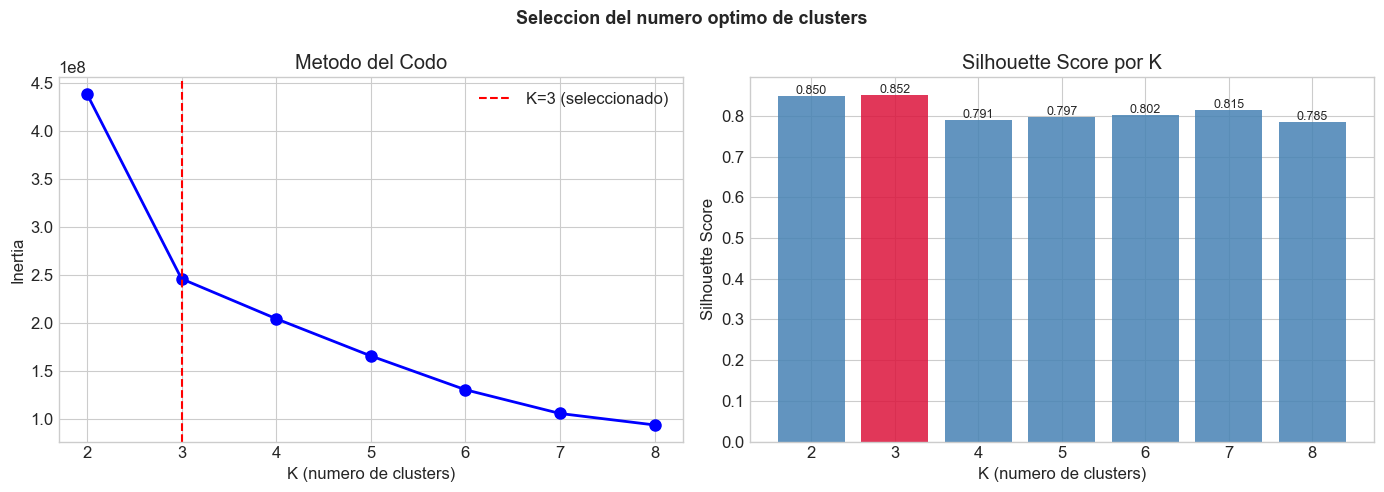

In [5]:
K_range = range(2, 9)

inertias = []

silhouettes = []


# Submuestra para silhouette (es O(n^2) en distancia)

n_sample = min(50_000, len(X_train))

rng_idx = np.random.RandomState(42)

sample_idx = rng_idx.choice(len(X_train), n_sample, replace=False)

X_sample = X_train[sample_idx]


print('Evaluando K-Means para K=2..8...')

print(f'  (silhouette sobre submuestra de {n_sample:,})')

print()

for k in K_range:

    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)

    km.fit(X_train)

    inertias.append(km.inertia_)

    

    labels_sample = km.predict(X_sample)

    sil = silhouette_score(X_sample, labels_sample)

    silhouettes.append(sil)

    print(f'  K={k}: inertia={km.inertia_:>14,.0f}  silhouette={sil:.4f}')


# Seleccion automatica

best_k_idx = np.argmax(silhouettes)

BEST_K = list(K_range)[best_k_idx]

print(f'\n-> Mejor K por silhouette: K={BEST_K} (score={silhouettes[best_k_idx]:.4f})')


# Graficas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=8)

axes[0].axvline(BEST_K, color='red', linestyle='--', lw=1.5,

                label=f'K={BEST_K} (seleccionado)')

axes[0].set(xlabel='K (numero de clusters)', ylabel='Inertia',

            title='Metodo del Codo')

axes[0].legend()


colors = ['steelblue'] * len(list(K_range))

colors[best_k_idx] = 'crimson'

axes[1].bar(list(K_range), silhouettes, color=colors, alpha=0.85)

axes[1].set(xlabel='K (numero de clusters)', ylabel='Silhouette Score',

            title='Silhouette Score por K')

for i, (k, s) in enumerate(zip(K_range, silhouettes)):

    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)


plt.suptitle('Seleccion del numero optimo de clusters',

             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()

## 5. K-Means Final: Entrenamiento y Análisis de Clusters


Entrenamos K-Means con K óptimo y analizamos qué representa cada cluster.

Distribucion de clusters en train (K=3):
  Cluster 0:   32,127 muestras (2.5%)
  Cluster 1: 1,237,727 muestras (95.2%)
  Cluster 2:   30,207 muestras (2.3%)


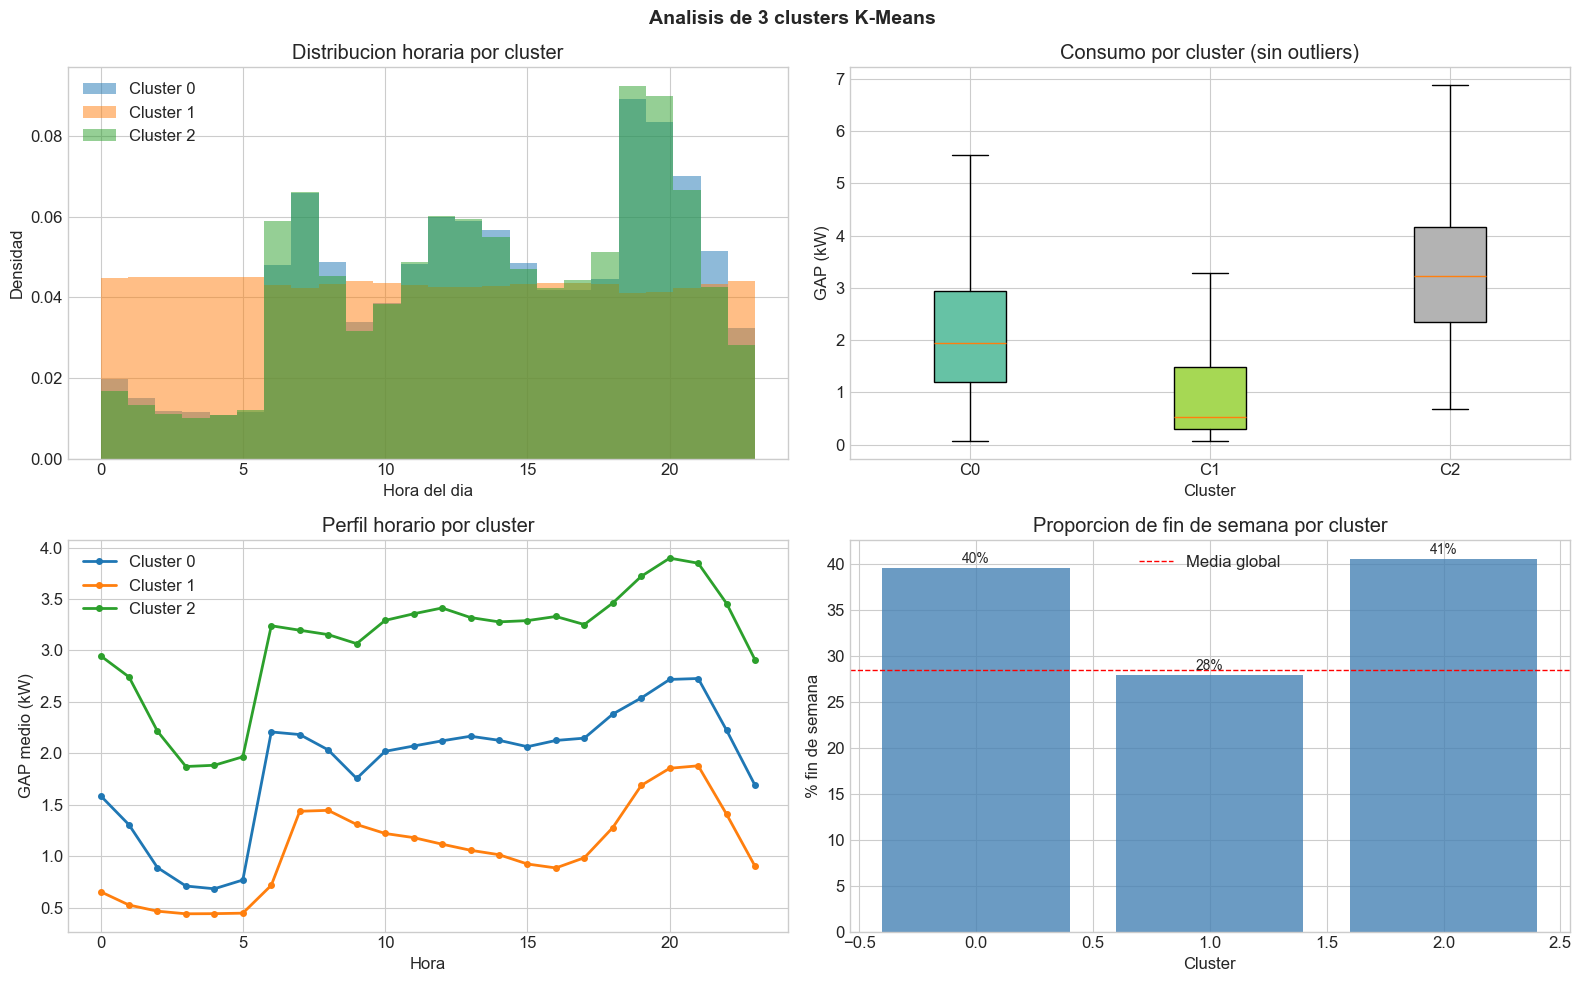


Resumen por cluster:
   Cluster  Hora media   GAP medio   % FdS         N
  --------------------------------------------------
         0        13.8h      2.154 kW     40%    32,127
         1        11.4h      1.044 kW     28%  1,237,727
         2        13.8h      3.343 kW     41%    30,207


In [6]:
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)

kmeans.fit(X_train)


cluster_train = kmeans.predict(X_train)

cluster_val   = kmeans.predict(X_val)

cluster_test  = kmeans.predict(X_test)


print(f'Distribucion de clusters en train (K={BEST_K}):')

for c in range(BEST_K):

    n = (cluster_train == c).sum()

    print(f'  Cluster {c}: {n:>8,} muestras ({n/len(cluster_train)*100:.1f}%)')


# Analisis temporal

df_analysis = df_train.copy()

df_analysis['cluster'] = cluster_train

df_analysis['hour'] = df_analysis.index.hour

df_analysis['is_weekend'] = df_analysis.index.dayofweek >= 5


fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# 1. Distribucion horaria por cluster

for c in range(BEST_K):

    mask = df_analysis['cluster'] == c

    axes[0, 0].hist(df_analysis.loc[mask, 'hour'], bins=24, alpha=0.5,

                     label=f'Cluster {c}', density=True)

axes[0, 0].set(xlabel='Hora del dia', ylabel='Densidad',

                title='Distribucion horaria por cluster')

axes[0, 0].legend()


# 2. Consumo por cluster (boxplot)

data_for_box = [df_analysis.loc[df_analysis['cluster'] == c,

                'Global_active_power'].values for c in range(BEST_K)]

bp = axes[0, 1].boxplot(data_for_box, labels=[f'C{c}' for c in range(BEST_K)],

                         patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'],

                         plt.cm.Set2(np.linspace(0, 1, BEST_K))):

    patch.set_facecolor(color)

axes[0, 1].set(xlabel='Cluster', ylabel='GAP (kW)',

                title='Consumo por cluster (sin outliers)')


# 3. Perfil horario medio

for c in range(BEST_K):

    mask = df_analysis['cluster'] == c

    hourly = df_analysis.loc[mask].groupby('hour')['Global_active_power'].mean()

    axes[1, 0].plot(hourly.index, hourly.values, 'o-', label=f'Cluster {c}',

                     lw=2, markersize=4)

axes[1, 0].set(xlabel='Hora', ylabel='GAP medio (kW)',

                title='Perfil horario por cluster')

axes[1, 0].legend()


# 4. % fin de semana

we_pct = [df_analysis.loc[df_analysis['cluster'] == c, 'is_weekend'].mean() * 100

           for c in range(BEST_K)]

bars = axes[1, 1].bar(range(BEST_K), we_pct, color='steelblue', alpha=0.8)

axes[1, 1].axhline(df_analysis['is_weekend'].mean() * 100,

                     color='red', linestyle='--', lw=1, label='Media global')

axes[1, 1].set(xlabel='Cluster', ylabel='% fin de semana',

                title='Proporcion de fin de semana por cluster')

axes[1, 1].legend()

for bar, pct in zip(bars, we_pct):

    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,

                     f'{pct:.0f}%', ha='center', fontsize=10)


plt.suptitle(f'Analisis de {BEST_K} clusters K-Means',

             fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()


# Resumen

print('\nResumen por cluster:')

print(f'  {"Cluster":>8s}  {"Hora media":>10s}  {"GAP medio":>10s}  {"% FdS":>6s}  {"N":>8s}')

print('  ' + '-' * 50)

for c in range(BEST_K):

    sub = df_analysis[df_analysis['cluster'] == c]

    print(f'  {c:>8d}  {sub["hour"].mean():>10.1f}h  '

          f'{sub["Global_active_power"].mean():>9.3f} kW  '

          f'{sub["is_weekend"].mean()*100:>5.0f}%  '

          f'{len(sub):>8,}')

## 6. Cluster Features (One-Hot Encoding)


Codificamos cluster_id como **one-hot** (no ordinal) para que IF no asuma

orden entre clusters.


```

Features totales = 17 base + K one-hot = 17 + K

```

In [7]:
def add_cluster_onehot(X, cluster_labels, n_clusters):

    '''Anade columnas one-hot del cluster_id a la matriz de features.'''

    onehot = np.zeros((len(cluster_labels), n_clusters), dtype=np.float64)

    for i, c in enumerate(cluster_labels):

        onehot[i, c] = 1.0

    return np.hstack([X, onehot])


X_train_aug = add_cluster_onehot(X_train, cluster_train, BEST_K)

X_val_aug   = add_cluster_onehot(X_val,   cluster_val,   BEST_K)

X_test_aug  = add_cluster_onehot(X_test,  cluster_test,  BEST_K)


feat_names_aug = feat_names + [f'cluster_{i}' for i in range(BEST_K)]


print(f'Features base:      {len(feat_names)}')

print(f'Clusters (one-hot): {BEST_K}')

print(f'Features totales:   {len(feat_names_aug)}')

print()

print(f'X_train_aug: {X_train_aug.shape}')

print(f'X_val_aug:   {X_val_aug.shape}')

print(f'X_test_aug:  {X_test_aug.shape}')

Features base:      17
Clusters (one-hot): 3
Features totales:   20

X_train_aug: (1300061, 20)
X_val_aug:   (144452, 20)
X_test_aug:  (604999, 20)


## 7. Estrategia A: IF Separado por Cluster


Un Isolation Forest independiente entrenado **solo con datos de su cluster**.


- **Ventaja**: cada IF se especializa en su régimen de consumo

- **Desventaja**: clusters pequeños -> pocos datos -> IF inestable;

  necesitamos gestionar K modelos en edge

In [8]:
print('ESTRATEGIA A: IF por cluster')

print('=' * 60)


models_per_cluster = {}

t0 = time.time()


for c in range(BEST_K):

    mask_c = (cluster_train == c)

    X_c = X_train[mask_c]  # 17 features base (ya en su cluster)

    

    if_c = IsolationForest(

        n_estimators=300, contamination='auto',

        max_features=0.8, random_state=42, n_jobs=-1

    )

    if_c.fit(X_c)

    models_per_cluster[c] = if_c

    print(f'  Cluster {c}: {mask_c.sum():>8,} muestras, '

          f'offset={if_c.offset_:.4f}')


t_train_A = time.time() - t0

print(f'\nEntrenamiento total: {t_train_A:.2f} s')


# Scoring: cada muestra -> IF de su cluster

def score_per_cluster(X_scaled, cluster_labels, models):

    '''Puntua cada muestra con el IF de su cluster asignado.'''

    scores = np.zeros(len(X_scaled))

    for c, model in models.items():

        mask = (cluster_labels == c)

        if mask.any():

            scores[mask] = -model.score_samples(X_scaled[mask])

    return scores


scores_val_A  = score_per_cluster(X_val,  cluster_val,  models_per_cluster)

scores_test_A = score_per_cluster(X_test, cluster_test, models_per_cluster)


auc_val_A = roc_auc_score(y_val, scores_val_A)

ap_val_A  = average_precision_score(y_val, scores_val_A)

print(f'\nVal:  AUC-ROC={auc_val_A:.4f}  AUC-PR={ap_val_A:.4f}')

ESTRATEGIA A: IF por cluster
  Cluster 0:   32,127 muestras, offset=-0.5000
  Cluster 1: 1,237,727 muestras, offset=-0.5000
  Cluster 2:   30,207 muestras, offset=-0.5000

Entrenamiento total: 3.67 s

Val:  AUC-ROC=0.9224  AUC-PR=0.7613


## 8. Estrategia B: IF Global con Cluster Features


Un solo Isolation Forest que recibe las 17 features base + K cluster one-hot.

El IF puede aprender internamente que diferentes clusters tienen diferentes

distribuciones normales.


- **Ventaja**: un solo modelo -> simple para edge

- **Ventaja**: el IF puede cruzar información entre features base y cluster

In [9]:
print('ESTRATEGIA B: IF global + cluster features')

print('=' * 60)


t0 = time.time()


model_if_B = IsolationForest(

    n_estimators=300,

    contamination='auto',

    max_features=0.8,

    max_samples='auto',

    bootstrap=False,

    random_state=42,

    n_jobs=-1

)

model_if_B.fit(X_train_aug)


t_train_B = time.time() - t0

print(f'Entrenamiento: {t_train_B:.2f} s')

print(f'  n_features:   {model_if_B.n_features_in_} (17 base + {BEST_K} cluster)')

print(f'  max_samples:  {model_if_B.max_samples_:,}')

print(f'  offset:       {model_if_B.offset_:.4f}')


scores_val_B  = -model_if_B.score_samples(X_val_aug)

scores_test_B = -model_if_B.score_samples(X_test_aug)


auc_val_B = roc_auc_score(y_val, scores_val_B)

ap_val_B  = average_precision_score(y_val, scores_val_B)

print(f'\nVal:  AUC-ROC={auc_val_B:.4f}  AUC-PR={ap_val_B:.4f}')

ESTRATEGIA B: IF global + cluster features
Entrenamiento: 4.34 s
  n_features:   20 (17 base + 3 cluster)
  max_samples:  256
  offset:       -0.5000

Val:  AUC-ROC=0.9085  AUC-PR=0.6293


## 9. Comparación A vs B -> Selección Automática


Seleccionamos la estrategia con mejor **AUC-PR** en validation

(AUC-PR es más informativa que AUC-ROC con clases desbalanceadas).

In [10]:
print('COMPARACION - ESTRATEGIA A vs B (Validation Set)')

print('=' * 65)

print(f'  {"Estrategia":35s} {"AUC-ROC":>8s}  {"AUC-PR":>8s}  {"Train":>7s}')

print('  ' + '-' * 63)

print(f'  {"A: IF por cluster":35s} {auc_val_A:>8.4f}  {ap_val_A:>8.4f}  {t_train_A:>6.1f}s')

print(f'  {"B: IF global + cluster features":35s} {auc_val_B:>8.4f}  {ap_val_B:>8.4f}  {t_train_B:>6.1f}s')


# Seleccion por AUC-PR

if ap_val_B >= ap_val_A:

    STRATEGY = 'B'

    scores_val  = scores_val_B

    scores_test = scores_test_B

    t_train = t_train_B

    print(f'\n-> Ganadora: Estrategia B (AUC-PR={ap_val_B:.4f})')

    print(f'   Ventaja edge: un solo modelo, {model_if_B.n_features_in_} features')

else:

    STRATEGY = 'A'

    scores_val  = scores_val_A

    scores_test = scores_test_A

    t_train = t_train_A

    print(f'\n-> Ganadora: Estrategia A (AUC-PR={ap_val_A:.4f})')

    print(f'   Nota: requiere {BEST_K} modelos IF en edge')

COMPARACION - ESTRATEGIA A vs B (Validation Set)
  Estrategia                           AUC-ROC    AUC-PR    Train
  ---------------------------------------------------------------
  A: IF por cluster                     0.9224    0.7613     3.7s
  B: IF global + cluster features       0.9085    0.6293     4.3s

-> Ganadora: Estrategia A (AUC-PR=0.7613)
   Nota: requiere 3 modelos IF en edge


## 10. Calibración del Umbral en Validation Set


Idéntico a NB03: `precision_recall_curve` evalúa **todos** los umbrales posibles.

Optimizamos F1 y reportamos F2 (que pesa recall 2x, más apropiado para seguridad).

In [11]:
def calibrate_threshold(y_true, scores, beta=1.0):

    '''

    Busca el umbral que maximiza F_beta sobre TODOS los thresholds posibles.

    Usa precision_recall_curve de sklearn (O(n log n), sin grid fijo).

    '''

    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)

    precisions = precisions[:-1]

    recalls    = recalls[:-1]


    fbeta = ((1 + beta**2) * precisions * recalls /

             (beta**2 * precisions + recalls + 1e-10))


    best_idx = np.argmax(fbeta)

    best_thr = thresholds[best_idx]


    n = len(thresholds)

    if n > 500:

        idx = np.linspace(0, n-1, 500, dtype=int)

    else:

        idx = np.arange(n)


    results_df = pd.DataFrame({

        'threshold':  thresholds[idx],

        'precision':  precisions[idx],

        'recall':     recalls[idx],

        'f1':         ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],

        'f2':         ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],

    })


    return best_thr, fbeta[best_idx], results_df


best_thr, best_f1, cal_df = calibrate_threshold(y_val, scores_val, beta=1.0)

_, best_f2, _ = calibrate_threshold(y_val, scores_val, beta=2.0)


print(f'Umbral optimo (val, F1): {best_thr:.6f}')

print(f'  F1 en val: {best_f1:.4f}')

print(f'  F2 en val: {best_f2:.4f}')

Umbral optimo (val, F1): 0.559491
  F1 en val: 0.7175
  F2 en val: 0.7693


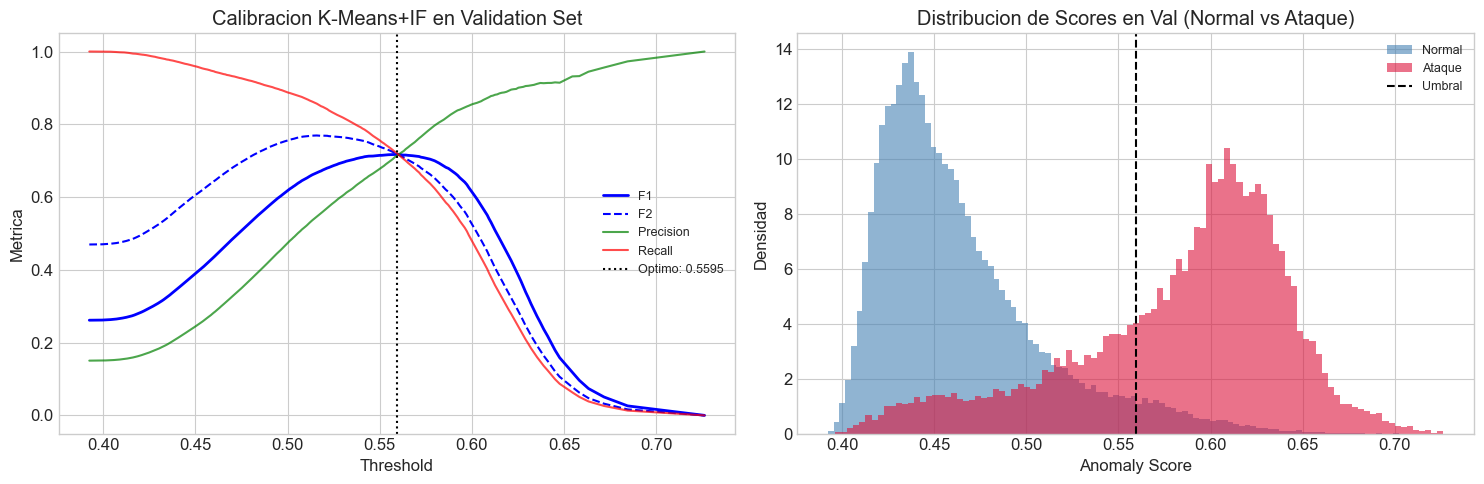

In [12]:
# Visualizacion calibracion + distribucion de scores en val

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


ax = axes[0]

ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')

ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')

ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5,

        label='Precision', alpha=0.7)

ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5,

        label='Recall', alpha=0.7)

ax.axvline(best_thr, color='k', linestyle=':', lw=1.5,

           label=f'Optimo: {best_thr:.4f}')

ax.set(xlabel='Threshold', ylabel='Metrica',

       title='Calibracion K-Means+IF en Validation Set')

ax.legend(fontsize=9)


ax = axes[1]

ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',

        label='Normal', density=True)

ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',

        label='Ataque', density=True)

ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Umbral')

ax.set(xlabel='Anomaly Score', ylabel='Densidad',

       title='Distribucion de Scores en Val (Normal vs Ataque)')

ax.legend(fontsize=9)


plt.tight_layout()

plt.show()

## 11. Evaluación RAW (sin post-procesamiento)


Métricas punto-a-punto antes del filtro de votación temporal.

In [13]:
y_pred = (scores_test > best_thr).astype(int)


print('=' * 60)

print(f'METRICAS - K-MEANS+IF (Estrategia {STRATEGY}, RAW)')

print('=' * 60)

print()

print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))


f1   = f1_score(y_test, y_pred)

f2   = fbeta_score(y_test, y_pred, beta=2)

prec = precision_score(y_test, y_pred)

rec  = recall_score(y_test, y_pred)

auc_roc = roc_auc_score(y_test, scores_test)

auc_pr  = average_precision_score(y_test, scores_test)


print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')

print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICAS - K-MEANS+IF (Estrategia A, RAW)

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95    508282
      Ataque       0.75      0.76      0.76     96717

    accuracy                           0.92    604999
   macro avg       0.85      0.86      0.85    604999
weighted avg       0.92      0.92      0.92    604999

AUC-ROC: 0.9270  |  AUC-PR: 0.7644
F1: 0.7563  |  F2: 0.7586  |  Precision: 0.7525  |  Recall: 0.7601


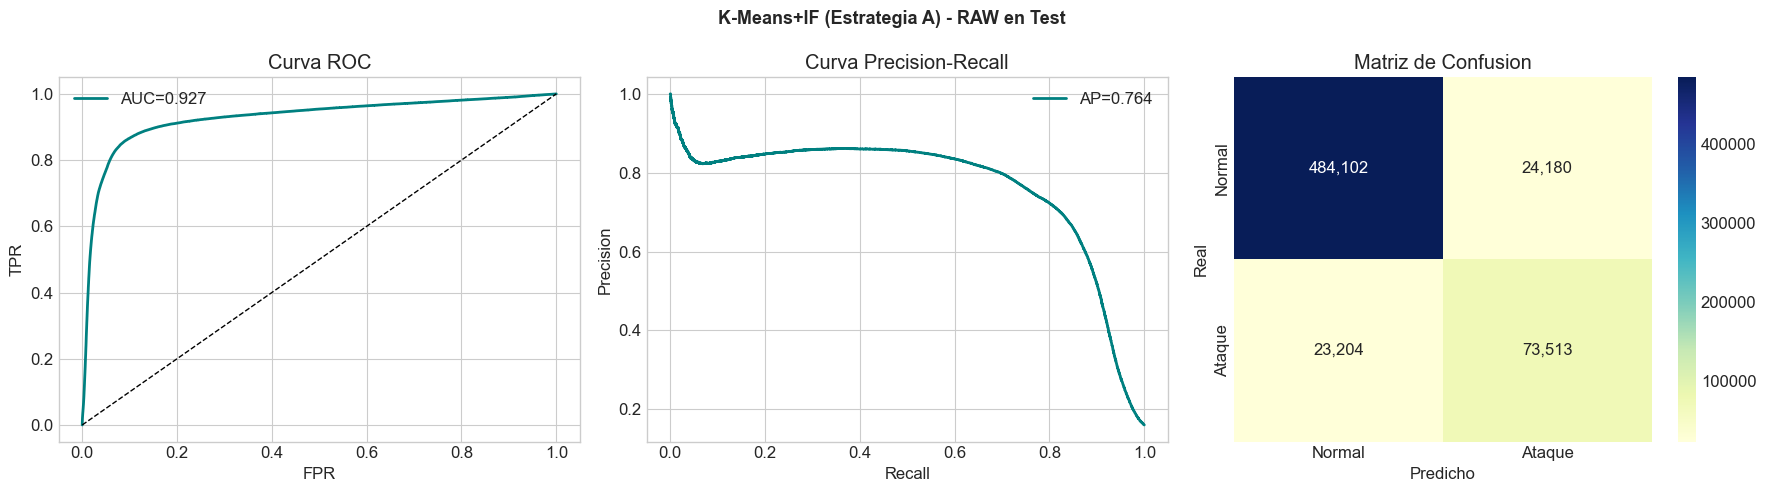

In [14]:
# ROC + PR + Matriz de Confusion (RAW)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


fpr, tpr, _ = roc_curve(y_test, scores_test)

axes[0].plot(fpr, tpr, 'teal', lw=2, label=f'AUC={auc_roc:.3f}')

axes[0].plot([0,1],[0,1],'k--', lw=1)

axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')

axes[0].legend()


pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)

axes[1].plot(rc_c, pr_c, 'teal', lw=2, label=f'AP={auc_pr:.3f}')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')

axes[1].legend()


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt=',d', cmap='YlGnBu',

            ax=axes[2], xticklabels=['Normal','Ataque'],

            yticklabels=['Normal','Ataque'])

axes[2].set(xlabel='Predicho', ylabel='Real', title='Matriz de Confusion')


plt.suptitle(f'K-Means+IF (Estrategia {STRATEGY}) - RAW en Test',

             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()

## 12. Post-procesamiento Temporal — Filtro de Votación


Idéntico a NB03. Explotamos que los FP naturales son puntos aislados (1-3 min)

mientras que los TP de ataques FDI son episodios sostenidos (15-120 min).


Para cada minuto `t`, alarma si >= K de las últimas W predicciones son positivas.

In [15]:
def temporal_vote_vectorized(y_pred, W, K):

    '''

    Filtro de votacion causal vectorizado.

    Para cada t: alarma si >= K de las ultimas W predicciones son positivas.

    Usa cumsum -> O(n).

    '''

    cum = np.concatenate([[0], np.cumsum(y_pred)])

    n = len(y_pred)

    ends = np.arange(1, n + 1)

    starts = np.maximum(0, ends - W)

    votes = cum[ends] - cum[starts]

    return (votes >= K).astype(int)



# Grid search de (W, K) en validation set

y_pred_val_raw = (scores_val > best_thr).astype(int)


print(f'Predicciones raw en val: {y_pred_val_raw.sum():,} positivos '

      f'({y_pred_val_raw.mean()*100:.1f}%)')

print()


W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]

best_wk_f1, best_W, best_K = 0, 3, 2

grid_results = []


for W in W_candidates:

    for K in range(2, W + 1):

        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)

        f1_sm = f1_score(y_val, y_sm)

        pr_sm = precision_score(y_val, y_sm, zero_division=0)

        rc_sm = recall_score(y_val, y_sm)

        f2_sm = fbeta_score(y_val, y_sm, beta=2)

        grid_results.append({

            'W': W, 'K': K, 'f1': f1_sm, 'f2': f2_sm,

            'precision': pr_sm, 'recall': rc_sm,

            'n_pos': y_sm.sum()

        })

        if f1_sm > best_wk_f1:

            best_wk_f1, best_W, best_K = f1_sm, W, K


grid_df = pd.DataFrame(grid_results)


print(f'Mejor (W, K) en val: W={best_W}, K={best_K}')

best_row = grid_df.loc[grid_df['f1'].idxmax()]

print(f'  F1:        {best_row["f1"]:.4f}')

print(f'  F2:        {best_row["f2"]:.4f}')

print(f'  Precision: {best_row["precision"]:.4f}')

print(f'  Recall:    {best_row["recall"]:.4f}')

print()


f1_raw_val  = f1_score(y_val, y_pred_val_raw)

pr_raw_val  = precision_score(y_val, y_pred_val_raw, zero_division=0)

rc_raw_val  = recall_score(y_val, y_pred_val_raw)

print(f'Val RAW:      F1={f1_raw_val:.4f}  P={pr_raw_val:.4f}  R={rc_raw_val:.4f}')

print(f'Val SMOOTHED: F1={best_wk_f1:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

delta_f1 = best_wk_f1 - f1_raw_val

print(f'  Mejora F1: +{delta_f1:.4f} ({delta_f1/(f1_raw_val+1e-10)*100:+.0f}%)')

Predicciones raw en val: 21,903 positivos (15.2%)

Mejor (W, K) en val: W=5, K=3
  F1:        0.7398
  F2:        0.7348
  Precision: 0.7483
  Recall:    0.7315

Val RAW:      F1=0.7175  P=0.7148  R=0.7202
Val SMOOTHED: F1=0.7398  P=0.7483  R=0.7315
  Mejora F1: +0.0223 (+3%)


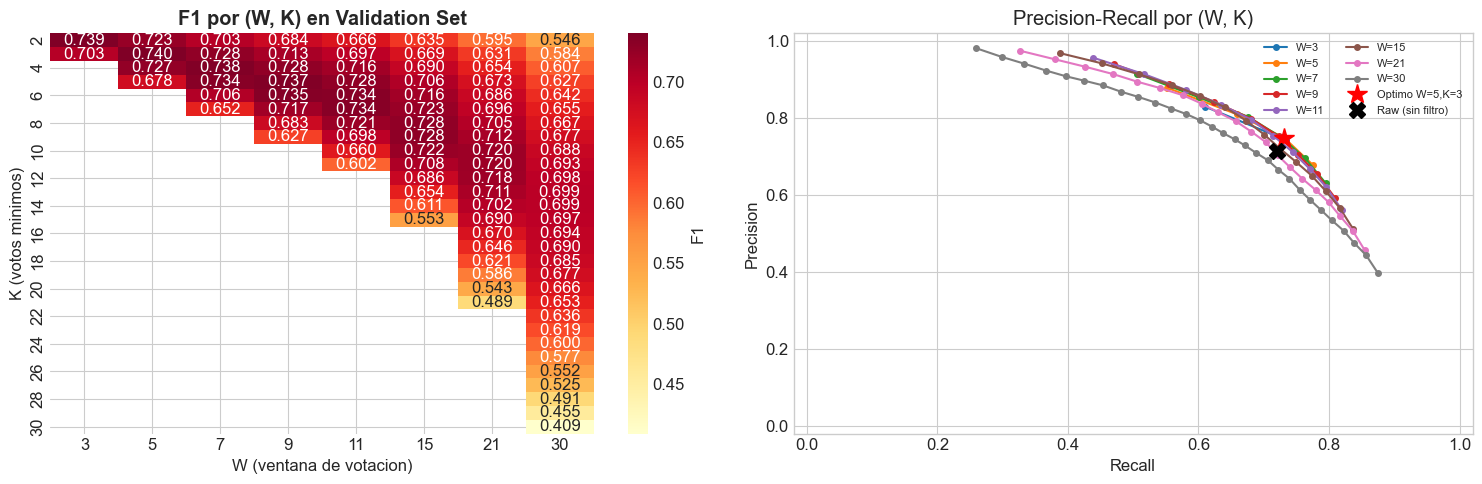

In [16]:
# Visualizar grid search

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


pivot = grid_df.pivot_table(index='K', columns='W', values='f1')

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],

            cbar_kws={'label': 'F1'})

axes[0].set_title('F1 por (W, K) en Validation Set', fontweight='bold')

axes[0].set_xlabel('W (ventana de votacion)')

axes[0].set_ylabel('K (votos minimos)')


ax = axes[1]

for W_val in W_candidates:

    sub = grid_df[grid_df['W'] == W_val]

    ax.plot(sub['recall'], sub['precision'], 'o-', label=f'W={W_val}', markersize=4)

ax.plot(best_row['recall'], best_row['precision'], '*', color='red',

        markersize=15, zorder=10, label=f'Optimo W={best_W},K={best_K}')

ax.plot(rc_raw_val, pr_raw_val, 'X', color='black',

        markersize=12, zorder=10, label='Raw (sin filtro)')

ax.set(xlabel='Recall', ylabel='Precision',

       title='Precision-Recall por (W, K)', xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))

ax.legend(fontsize=8, ncol=2)


plt.tight_layout()

plt.show()

## 13. Evaluación Smoothed en Test

In [17]:
y_pred_raw    = (scores_test > best_thr).astype(int)

y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)


f1_s   = f1_score(y_test, y_pred_smooth)

f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)

prec_s = precision_score(y_test, y_pred_smooth)

rec_s  = recall_score(y_test, y_pred_smooth)


print('=' * 70)

print('COMPARACION - K-MEANS+IF: RAW vs TEMPORAL VOTING')

print('=' * 70)

print()

print(f'  {"Metrica":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')

print('  ' + '-' * 45)

for name, raw_v, sm_v in [

    ('F1',        f1,   f1_s),

    ('F2',        f2,   f2_s),

    ('Precision',  prec,  prec_s),

    ('Recall',     rec,   rec_s),

]:

    delta = sm_v - raw_v

    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')

print()

print(f'  Filtro: W={best_W}, K={best_K} (votacion causal)')

print(f'  Overhead edge: O(1)/muestra, buffer circular de {best_W} enteros')

print()

print(classification_report(y_test, y_pred_smooth,

                             target_names=['Normal', 'Ataque']))

COMPARACION - K-MEANS+IF: RAW vs TEMPORAL VOTING

  Metrica             Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.7563     0.7684    +0.0122
  F2               0.7586     0.7682    +0.0097
  Precision        0.7525     0.7688    +0.0164
  Recall           0.7601     0.7680    +0.0080

  Filtro: W=5, K=3 (votacion causal)
  Overhead edge: O(1)/muestra, buffer circular de 5 enteros

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96    508282
      Ataque       0.77      0.77      0.77     96717

    accuracy                           0.93    604999
   macro avg       0.86      0.86      0.86    604999
weighted avg       0.93      0.93      0.93    604999



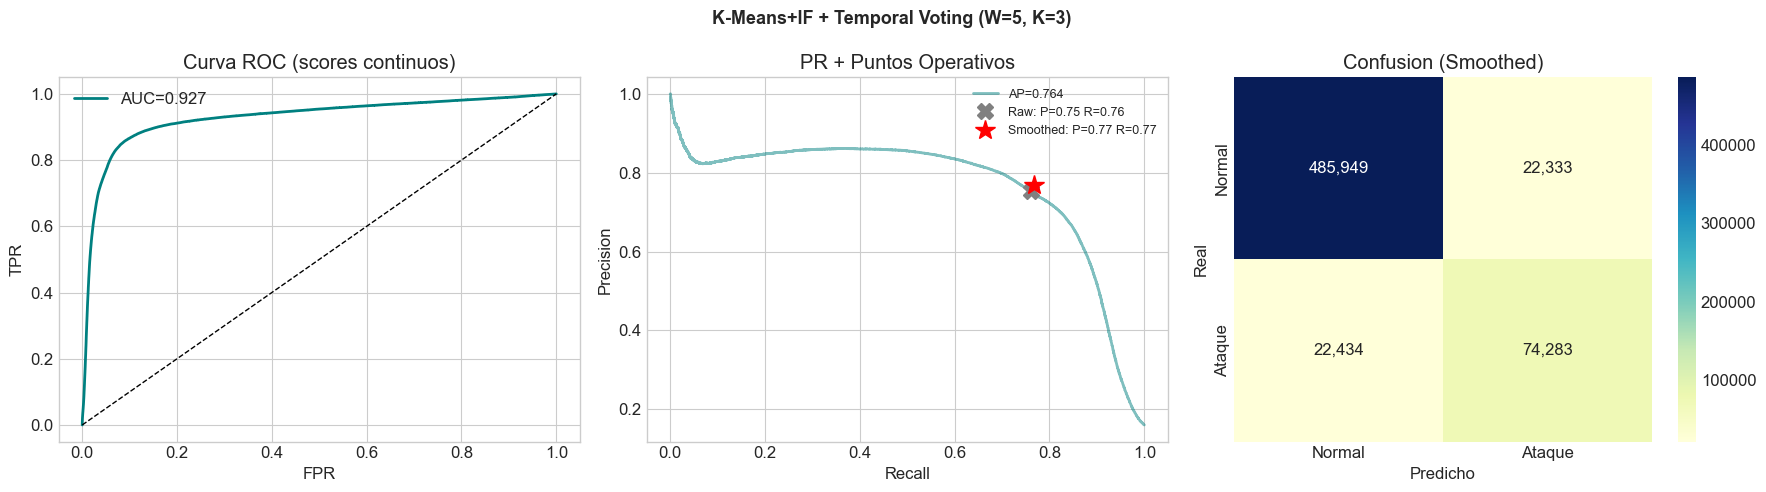

In [18]:
# ROC + PR + CM - SMOOTHED

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)

axes[0].plot(fpr_s, tpr_s, 'teal', lw=2, label=f'AUC={auc_roc:.3f}')

axes[0].plot([0,1],[0,1],'k--', lw=1)

axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC (scores continuos)')

axes[0].legend()


pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)

axes[1].plot(rc_c2, pr_c2, 'teal', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)

axes[1].plot(rec, prec, 'X', color='gray', markersize=12,

             label=f'Raw: P={prec:.2f} R={rec:.2f}')

axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,

             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')

axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Puntos Operativos')

axes[1].legend(fontsize=9)


cm_s = confusion_matrix(y_test, y_pred_smooth)

sns.heatmap(cm_s, annot=True, fmt=',d', cmap='YlGnBu', ax=axes[2],

            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])

axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion (Smoothed)')


plt.suptitle(f'K-Means+IF + Temporal Voting (W={best_W}, K={best_K})',

             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()

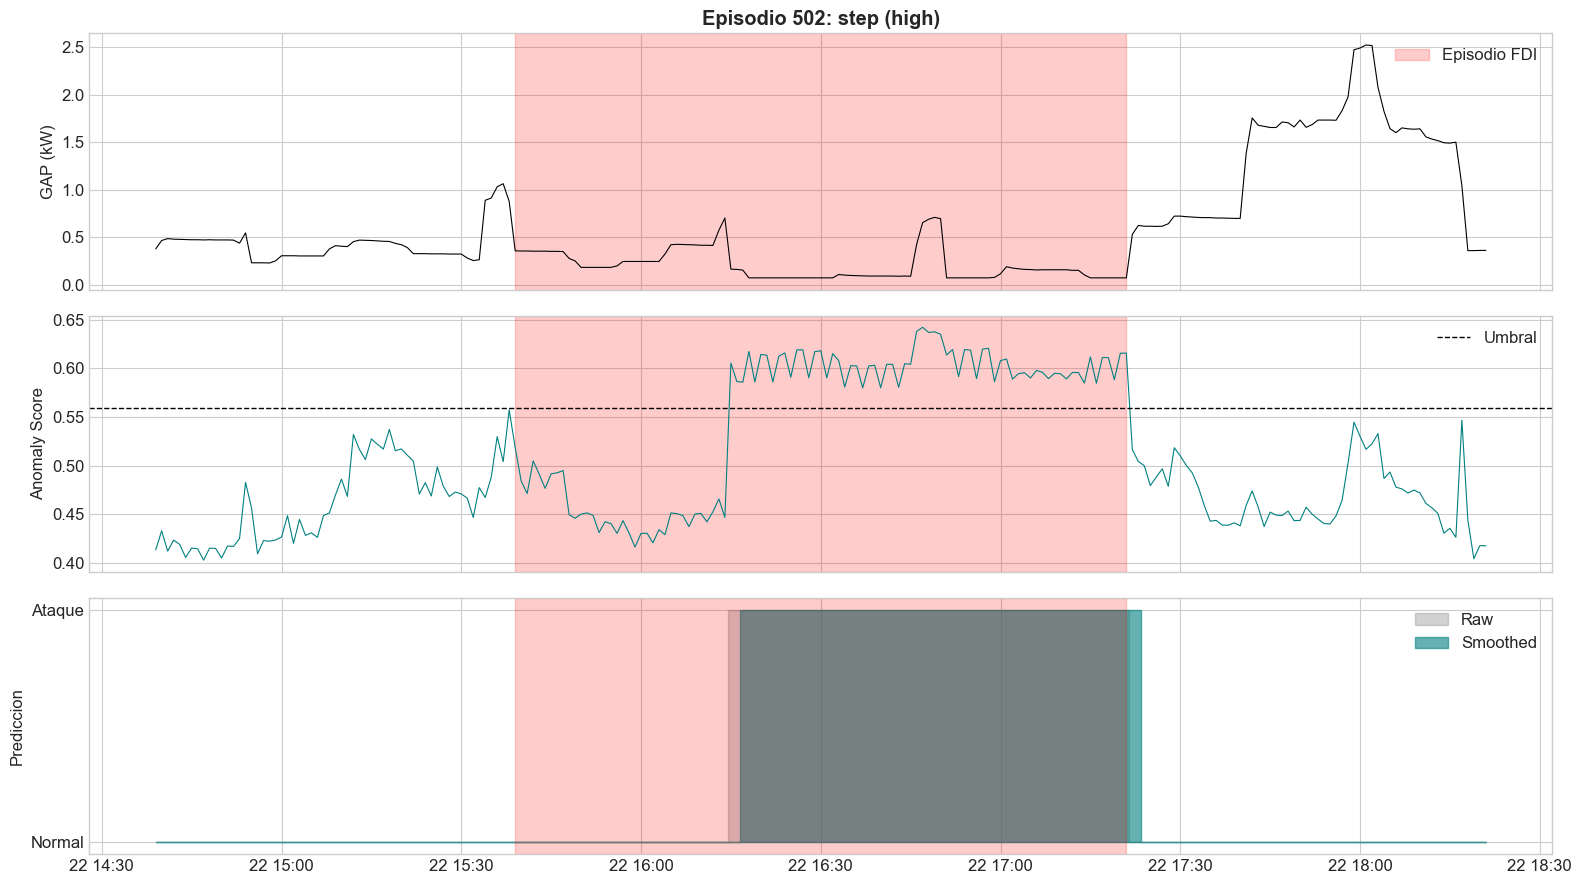

In [19]:
# Visualizar efecto del filtro sobre un episodio ejemplo

ep_ids = df_test.loc[df_test['episode_id'] >= 0, 'episode_id'].unique()

example_ep = None

for ep in ep_ids[:30]:

    mask = (df_test['episode_id'] == ep).values

    if y_pred_smooth[mask].any():

        example_ep = ep

        break


if example_ep is not None:

    mask = df_test['episode_id'] == example_ep

    ep_data = df_test[mask]

    ep_start = ep_data.index[0]

    ep_end   = ep_data.index[-1]


    ctx_start = ep_start - pd.Timedelta(minutes=60)

    ctx_end   = ep_end + pd.Timedelta(minutes=60)

    ctx = df_test.loc[ctx_start:ctx_end]


    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)


    axes[0].plot(ctx.index, ctx['Global_active_power'], 'k-', lw=0.8)

    axes[0].axvspan(ep_start, ep_end, alpha=0.2, color='red', label='Episodio FDI')

    axes[0].set_ylabel('GAP (kW)')

    axes[0].set_title(f'Episodio {example_ep}: {ep_data["attack_type"].iloc[0]} '

                       f'({ep_data["severity"].iloc[0]})', fontweight='bold')

    axes[0].legend()


    ctx_idx = df_test.index.get_indexer(ctx.index)

    valid = ctx_idx >= 0

    ctx_scores = scores_test[ctx_idx[valid]]

    axes[1].plot(ctx.index[valid], ctx_scores, 'teal', lw=0.8)

    axes[1].axhline(best_thr, color='k', linestyle='--', lw=1, label='Umbral')

    axes[1].axvspan(ep_start, ep_end, alpha=0.2, color='red')

    axes[1].set_ylabel('Anomaly Score')

    axes[1].legend()


    ctx_raw = y_pred_raw[ctx_idx[valid]]

    ctx_sm  = y_pred_smooth[ctx_idx[valid]]

    ctx_times = ctx.index[valid]

    axes[2].fill_between(ctx_times, 0, ctx_raw, alpha=0.35, color='gray',

                          step='mid', label='Raw')

    axes[2].fill_between(ctx_times, 0, ctx_sm, alpha=0.6, color='teal',

                          step='mid', label='Smoothed')

    axes[2].axvspan(ep_start, ep_end, alpha=0.2, color='red')

    axes[2].set_ylabel('Prediccion')

    axes[2].set_yticks([0, 1])

    axes[2].set_yticklabels(['Normal', 'Ataque'])

    axes[2].legend()


    plt.tight_layout()

    plt.show()

else:

    print('No se encontro episodio ejemplo adecuado para visualizar.')

## 14. Recall por Tipo de Ataque x Severidad (Smoothed)

Recall por tipo x severidad:
  Tipo                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling             13,449    0.558    0.867    0.959    0.801
  offset              13,898    0.780    0.945    0.964    0.905
  noise               14,357    0.739    0.911    0.939    0.868
  ramp                14,006    0.565    0.714    0.806    0.694
  step                13,731    0.560    0.625    0.620    0.603
  replay              14,084    0.528    0.726    0.798    0.689
  voltage_spoof       13,192    0.614    0.859    0.970    0.817


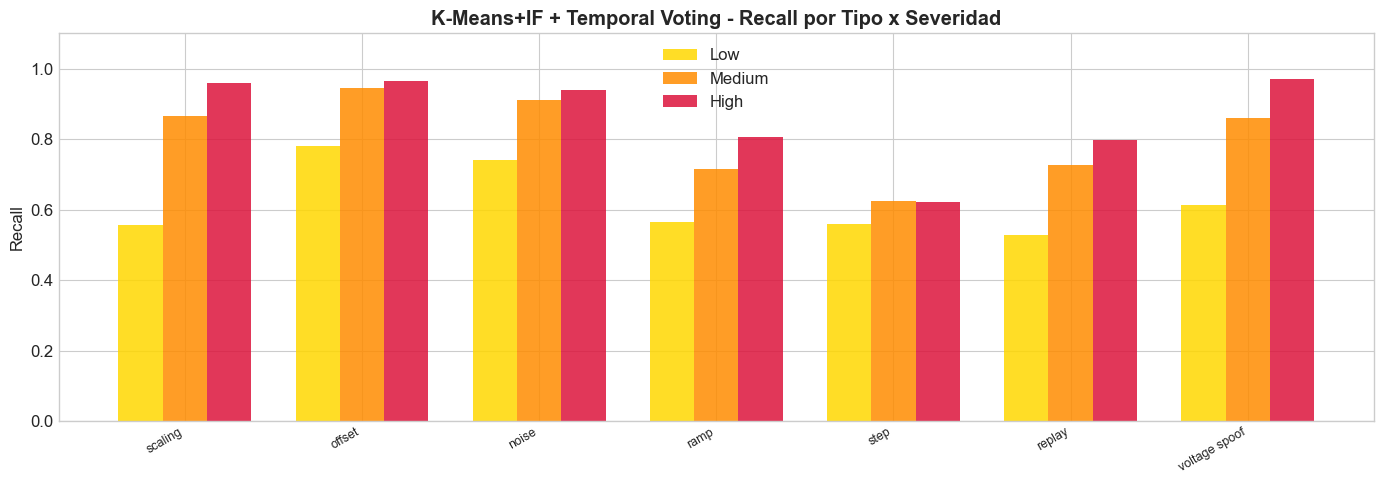

In [20]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,

                            attack_types_list, title_prefix):

    '''Tabla + grafico de barras de recall por tipo x severidad.'''

    print(f'Recall por tipo x severidad:')

    print(f'  {"Tipo":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')

    print('  ' + '-' * 55)


    recall_data = {}

    for t in attack_types_list:

        mask_t = (attack_types_col == t)

        n_t = (mask_t & (y_true == 1)).sum()

        row = f'  {t:18s} {n_t:>7,}'

        for sev in ['low', 'medium', 'high']:

            mask = mask_t & (severity_col == sev) & (y_true == 1)

            n = mask.sum()

            if n > 0:

                r = (y_pred[mask] == 1).sum() / n

                row += f' {r:>8.3f}'

            else:

                r = np.nan

                row += f' {"---":>8s}'

            recall_data[(t, sev)] = r

        mask_all = mask_t & (y_true == 1)

        n_all = mask_all.sum()

        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0

        row += f' {r_t:>8.3f}'

        print(row)


    fig, ax = plt.subplots(figsize=(14, 5))

    x = np.arange(len(attack_types_list))

    w = 0.25

    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}

    for i, (sev, c) in enumerate(sev_colors.items()):

        vals = []

        for t in attack_types_list:

            v = recall_data.get((t, sev), 0)

            vals.append(v if not (isinstance(v, float) and np.isnan(v)) else 0)

        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)

    ax.set_xticks(x + w)

    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],

                        rotation=30, ha='right', fontsize=9)

    ax.set_ylabel('Recall')

    ax.set_ylim(0, 1.1)

    ax.set_title(f'{title_prefix} - Recall por Tipo x Severidad', fontweight='bold')

    ax.legend()

    plt.tight_layout()

    plt.show()


    return recall_data


recall_data = recall_by_type_severity(

    attack_types_col=df_test['attack_type'].values,

    severity_col=df_test['severity'].values,

    y_true=y_test,

    y_pred=y_pred_smooth,

    attack_types_list=ATTACK_TYPES,

    title_prefix='K-Means+IF + Temporal Voting'

)

## 15. Latencia de Deteccion (Smoothed)

In [21]:
def compute_detection_latency(df_preds, score_col, threshold):

    '''Latencia de deteccion por episodio de ataque.'''

    results = []

    attacked = df_preds[df_preds['episode_id'] >= 0]

    for ep_id, group in attacked.groupby('episode_id'):

        group = group.sort_index()

        detections = group[group[score_col] > threshold]

        ep_start = group.index[0]

        results.append({

            'episode_id': ep_id,

            'type': group['attack_type'].iloc[0],

            'severity': group['severity'].iloc[0],

            'duration_min': len(group),

            'latency_min': (

                (detections.index[0] - ep_start).total_seconds() / 60

                if len(detections) > 0 else np.nan

            ),

            'detected': len(detections) > 0

        })

    return pd.DataFrame(results)


def print_latency_summary(lat_df):

    '''Resumen de latencia por severidad.'''

    det_rate = lat_df['detected'].mean()

    detected = lat_df[lat_df['detected']]

    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan


    print(f'Deteccion por episodio: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')

    if not np.isnan(med_lat):

        print(f'Latencia mediana:       {med_lat:.1f} min')

    print()


    for sev in ['low', 'medium', 'high']:

        sub = lat_df[lat_df['severity'] == sev]

        if len(sub) == 0:

            continue

        det = sub['detected'].mean()

        det_sub = sub[sub['detected']]

        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan

        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'

        print(f'  {sev:8s}: deteccion {det:.0%}  |  latencia mediana {lat_s}')


    return det_rate, med_lat


df_test_scored = df_test.copy()

df_test_scored['kmif_pred_smooth'] = y_pred_smooth.astype(float)


lat_df = compute_detection_latency(df_test_scored, 'kmif_pred_smooth', 0.5)

det_rate, med_lat = print_latency_summary(lat_df)


print()

print(f'NOTA: El filtro de votacion anade latencia de hasta {best_W-1} min')

print(f'      respecto al raw (necesita acumular {best_K} votos de {best_W}).')

Deteccion por episodio: 98.6% (828/840)
Latencia mediana:       4.0 min

  low     : deteccion 96%  |  latencia mediana 10.0 min
  medium  : deteccion 100%  |  latencia mediana 3.0 min
  high    : deteccion 100%  |  latencia mediana 3.0 min

NOTA: El filtro de votacion anade latencia de hasta 4 min
      respecto al raw (necesita acumular 3 votos de 5).


## 16. Comparación con IF Baseline (NB03)


Cargamos `metrics_isolation_forest.json` generado por NB03 para comparar

directamente ambos modelos con las mismas condiciones.

In [22]:
nb03_path = os.path.join(DATA_DIR, 'metrics_isolation_forest.json')


if os.path.exists(nb03_path):

    with open(nb03_path) as f:

        m03 = json.load(f)

    

    print('=' * 75)

    print('COMPARACION FINAL: IF baseline (NB03)  vs  K-Means+IF (NB03b)')

    print('=' * 75)

    print()

    

    comparisons = [

        ('F1 (smoothed)',    m03.get('f1', 0),        f1_s),

        ('F2 (smoothed)',    m03.get('f2', 0),        f2_s),

        ('Precision (sm.)',  m03.get('precision', 0),  prec_s),

        ('Recall (sm.)',     m03.get('recall', 0),     rec_s),

        ('AUC-ROC',         m03.get('auc_roc', 0),    auc_roc),

        ('AUC-PR',          m03.get('auc_pr', 0),     auc_pr),

        ('Raw F1',          m03.get('raw_f1', 0),     f1),

        ('Raw Precision',   m03.get('raw_precision', 0), prec),

        ('Raw Recall',      m03.get('raw_recall', 0), rec),

    ]

    

    print(f'  {"Metrica":20s} {"IF (NB03)":>12s} {"K-Means+IF":>12s} {"Delta":>12s}')

    print('  ' + '-' * 60)

    for name, v_old, v_new in comparisons:

        delta = v_new - v_old

        arrow = '+' if delta > 0.0005 else ('-' if delta < -0.0005 else '=')

        print(f'  {name:20s} {v_old:>12.4f} {v_new:>12.4f} {delta:>+11.4f} {arrow}')

    

    print()

    print(f'  {"Edge":20s} {"IF (NB03)":>12s} {"K-Means+IF":>12s}')

    print('  ' + '-' * 46)

    size_nb03 = m03.get("model_size_kb", "?")

    ms_nb03 = m03.get("ms_per_sample", "?")

    nf_nb03 = m03.get("n_features", "?")

    print(f'  {"Features":20s} {str(nf_nb03):>12s}   (se calcula en S17)')

    print(f'  {"ms/muestra":20s} {str(ms_nb03):>12s}   (se calcula en S17)')

    print(f'  {"Temporal (W,K)":20s}  ({m03.get("temporal_W","?")},{m03.get("temporal_K","?")})         ({best_W},{best_K})')

    

else:

    print('metrics_isolation_forest.json no encontrado.')

    print('Ejecuta NB03 primero para generar las metricas baseline.')

    print()

    print('Metricas de K-Means+IF (este notebook):')

    print(f'  F1={f1_s:.4f}  F2={f2_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')

    print(f'  AUC-ROC={auc_roc:.4f}  AUC-PR={auc_pr:.4f}')

COMPARACION FINAL: IF baseline (NB03)  vs  K-Means+IF (NB03b)

  Metrica                 IF (NB03)   K-Means+IF        Delta
  ------------------------------------------------------------
  F1 (smoothed)              0.7433       0.7684     +0.0251 +
  F2 (smoothed)              0.7485       0.7682     +0.0197 +
  Precision (sm.)            0.7348       0.7688     +0.0340 +
  Recall (sm.)               0.7520       0.7680     +0.0160 +
  AUC-ROC                    0.9242       0.9270     +0.0028 +
  AUC-PR                     0.7586       0.7644     +0.0058 +
  Raw F1                     0.7359       0.7563     +0.0204 +
  Raw Precision              0.7261       0.7525     +0.0264 +
  Raw Recall                 0.7460       0.7601     +0.0141 +

  Edge                    IF (NB03)   K-Means+IF
  ----------------------------------------------
  Features                       17   (se calcula en S17)
  ms/muestra                  0.005   (se calcula en S17)
  Temporal (W,K)        (3,2) 

## 17. Edge Computing + Guardado

In [23]:
# Guardar modelo(s)

save_bundle = {

    'strategy': STRATEGY,

    'n_clusters': BEST_K,

    'kmeans': kmeans,

}

if STRATEGY == 'B':

    save_bundle['isolation_forest'] = model_if_B

else:

    save_bundle['isolation_forests'] = models_per_cluster


model_path = os.path.join(DATA_DIR, 'model_kmeans_if.pkl')

joblib.dump(save_bundle, model_path)

size_kb = os.path.getsize(model_path) / 1e3


joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_kmeans_if.pkl'))


# Timing: incluye KMeans predict + IF score (pipeline completo)

if STRATEGY == 'B':

    _ = model_if_B.score_samples(X_test_aug[:100])  # warmup

    times = []

    for _ in range(5):

        t0 = time.time()

        _cl = kmeans.predict(X_test)

        _X_aug = add_cluster_onehot(X_test, _cl, BEST_K)

        model_if_B.score_samples(_X_aug)

        times.append(time.time() - t0)

else:

    times = []

    for _ in range(5):

        t0 = time.time()

        _cl = kmeans.predict(X_test)

        score_per_cluster(X_test, _cl, models_per_cluster)

        times.append(time.time() - t0)


ms_avg = np.mean(times) / len(X_test) * 1000


print('=' * 60)

print('EDGE COMPUTING - K-MEANS+IF + TEMPORAL VOTING')

print('=' * 60)

strat_desc = 'IF global + cluster feat.' if STRATEGY == 'B' else f'{BEST_K} IFs por cluster'

n_feat = len(feat_names_aug) if STRATEGY == 'B' else len(feat_names)

print(f'  Estrategia:       {STRATEGY} ({strat_desc})')

print(f'  Clusters:         {BEST_K}')

print(f'  Features:         {n_feat}')

print(f'  Filtro temporal:  W={best_W}, K={best_K} (buffer {best_W} enteros)')

print(f'  Tamano en disco:  {size_kb:.1f} KB')

print(f'  Latencia:         {ms_avg:.4f} ms/muestra (KMeans + IF + filter)')

print(f'  Throughput:       {1000/ms_avg:,.0f} muestras/s')

print(f'  Granularidad:     1 minuto (tiempo real)')

print(f'  Entrenamiento:    {t_train:.1f} s')


# Guardar predicciones

df_out = df_test.copy()

df_out['kmif_score']       = scores_test

df_out['kmif_pred_raw']    = y_pred_raw

df_out['kmif_pred_smooth'] = y_pred_smooth

df_out['cluster']          = cluster_test

df_out.to_csv(os.path.join(DATA_DIR, 'predictions_kmeans_if.csv'))

lat_df.to_csv(os.path.join(DATA_DIR, 'latency_kmeans_if.csv'), index=False)


# Guardar metricas JSON

metrics = {

    'model': f'K-Means(K={BEST_K}) + IF + Temporal Voting (Strategy {STRATEGY})',

    'feature_mode': 'full + cluster_onehot' if STRATEGY == 'B' else 'full (per-cluster)',

    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),

    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),

    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),

    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),

    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),

    'threshold': round(float(best_thr), 6),

    'temporal_W': best_W, 'temporal_K': best_K,

    'n_clusters': BEST_K, 'strategy': STRATEGY,

    'silhouette_scores': {str(k): round(s, 4) for k, s in zip(K_range, silhouettes)},

    'scaler_ablation': ablation_results,

    'model_size_kb': round(size_kb, 1),

    'ms_per_sample': round(ms_avg, 4),

    'n_features': n_feat,

    'train_time_s': round(t_train, 2),

    'detection_rate': round(det_rate, 4),

    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,

    'granularity': '1 min',

    'feature_names': feat_names_aug if STRATEGY == 'B' else feat_names,

}


with open(os.path.join(DATA_DIR, 'metrics_kmeans_if.json'), 'w') as f:

    json.dump(metrics, f, indent=2)


print()

print('Guardado en data/:')

for fn in ['predictions_kmeans_if.csv', 'metrics_kmeans_if.json',

           'model_kmeans_if.pkl', 'scaler_kmeans_if.pkl',

           'latency_kmeans_if.csv']:

    print(f'  * {fn}')

EDGE COMPUTING - K-MEANS+IF + TEMPORAL VOTING
  Estrategia:       A (3 IFs por cluster)
  Clusters:         3
  Features:         17
  Filtro temporal:  W=5, K=3 (buffer 5 enteros)
  Tamano en disco:  17425.4 KB
  Latencia:         0.0082 ms/muestra (KMeans + IF + filter)
  Throughput:       121,948 muestras/s
  Granularidad:     1 minuto (tiempo real)
  Entrenamiento:    3.7 s

Guardado en data/:
  * predictions_kmeans_if.csv
  * metrics_kmeans_if.json
  * model_kmeans_if.pkl
  * scaler_kmeans_if.pkl
  * latency_kmeans_if.csv


## 18. Resumen


### K-Means + IF vs IF Baseline


| Aspecto | IF solo (NB03) | K-Means + IF (NB03b) |

|---|---|---|

| Contexto | Ninguno | Régimen de consumo via cluster |

| Features | 17 (full) | 17 + K one-hot |

| Hipótesis | "toda anomalía es igual" | "anomalía depende del contexto horario" |

| Normalización | RobustScaler (sin justificación) | RobustScaler (**validado** con ablación) |

| Edge overhead | IF score | KMeans predict (~us) + IF score |


### Interpretación


- Si K-Means+IF **mejora F1**: el contexto de régimen reduce FP de confusión entre

  patrones de consumo (madrugada vs pico), validando la hipótesis.

  

- Si K-Means+IF **no mejora F1**: las features cíclicas (hour_sin/cos, dow_sin/cos)

  ya capturan la temporalidad suficiente, y K-Means es redundante.

  **Esta conclusión es igualmente valiosa para el TFG.**


### Para la empresa


- Pipeline K-Means -> IF es **interpretable**: "tu fábrica tiene N regímenes de consumo,

  y esta anomalía ocurrió durante el régimen nocturno donde el consumo debería ser X"

- El overhead de K-Means predict en edge es **despreciable** (~1us por centroide)

- Es el modelo ideal para **despliegue en ESP32/RPi**: modelo pequeño, latencia baja


### Archivos generados


| Archivo | Contenido |

|---|---|

| `predictions_kmeans_if.csv` | Scores + predicciones raw/smooth + cluster por minuto |

| `metrics_kmeans_if.json` | Métricas completas + ablación + silhouette |

| `model_kmeans_if.pkl` | Bundle: KMeans + IF (Estrategia ganadora) |

| `scaler_kmeans_if.pkl` | RobustScaler fitted |

| `latency_kmeans_if.csv` | Latencia de detección por episodio |